In [7]:
import pandas as pd
import os

# 행과 열 모두 무제한으로 표시
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

Load raw data

In [9]:
file_path = os.getcwd()
data_path = os.path.join(file_path, '..', 'data', 'TEDS_Discharge.csv')
raw_data = pd.read_csv(data_path)
raw_data.head()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jeong-yunseong/Documents/programming/Phase_2/notebooks/../data/TEDS_Discharge.csv'

Check the shape of raw_data

In [ ]:
print('column_number:', len(raw_data.columns))
print('row_number:', len(raw_data))


column_number: 76
row_number: 1394138


Get missing rate of each columns

In [ ]:
import matplotlib.pyplot as plt
def missing_check(df: pd.DataFrame):
    missing_rate_dict = {col: -1.0 for col in df.columns}

    len_raw_data = 1394138

    for col_name in df.columns:
        col = df[col_name]
        if -9 in col.unique():
            missing_rate = float(col.value_counts()[-9] / len_raw_data)
            missing_rate_dict[col_name] = missing_rate
        else:
            missing_rate_dict[col_name] = 0

    missing_rate_df = pd.DataFrame.from_dict(missing_rate_dict, orient='index', columns=['missing_rate'])
    sorted_df = missing_rate_df.sort_values(ascending=False, by='missing_rate')
    sorted_df.to_csv('sorted_missing_rate.csv')
    print(sorted_df)

    

    sorted_df = sorted_df.sort_values(ascending=True, by='missing_rate')
    x = sorted_df.index
    y = sorted_df['missing_rate'].to_list()

    plt.figure(figsize=(8, 15))        
    plt.title("Missing Rate per Variable")
    plt.barh(x, y)
    plt.tick_params(axis="y", which="both", right=True, labelright=True)  
    plt.show()
    return sorted_df

missing_check(raw_data)

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
missing_rate_dict = {col: -1.0 for col in raw_data.columns}

len_raw_data = 1394138

for col_name in raw_data.columns:
    col = raw_data[col_name]
    if -9 in col.unique():
        missing_rate = float(col.value_counts()[-9] / len_raw_data)
        missing_rate_dict[col_name] = missing_rate
    else:
        missing_rate_dict[col_name] = 0

missing_rate_df = pd.DataFrame.from_dict(missing_rate_dict, orient='index', columns=['missing_rate'])
sorted_df = missing_rate_df.sort_values(ascending=False, by='missing_rate')
sorted_df.to_csv('sorted_missing_rate.csv')
sorted_df

,missing_rate
DETCRIM,0.847507
FREQ3_D,0.845651
ROUTE3,0.814318
FRSTUSE3,0.814016
FREQ3,0.813867
DETNLF,0.787276
DETNLF_D,0.769530
FREQ2_D,0.730202
PREG,0.665445
DAYWAIT,0.537257


변수별 결측치 비율 시각화

In [ ]:
import matplotlib.pyplot as plt

sorted_df = sorted_df.sort_values(ascending=True, by='missing_rate')
x = sorted_df.index
y = sorted_df['missing_rate'].to_list()

plt.figure(figsize=(8, 15))        
plt.title("Missing Rate per Variable")
plt.barh(x, y)
plt.tick_params(axis="y", which="both", right=True, labelright=True)  
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

SUBn들의 1과 -9의 비율

In [ ]:
row_num = len(raw_data)

print('SUB1(1):', round(raw_data['SUB1'].value_counts()[1] / row_num, 4))
print('SUB1(-9):', round(raw_data['SUB1'].value_counts()[-9] / row_num, 4))
print()
print('SUB2(1):', round(raw_data['SUB2'].value_counts()[1] / row_num, 4))
print('SUB2(-9):', round(raw_data['SUB2'].value_counts()[-9] / row_num, 4))
print()
print('SUB3(1):', round(raw_data['SUB3'].value_counts()[1] / row_num, 4))
print('SUB3(-9):', round(raw_data['SUB3'].value_counts()[-9] / row_num, 4))
print()
print('SUB1_D(1):', round(raw_data['SUB1_D'].value_counts()[1] / row_num, 4))
print('SUB1_D(-9):', round(raw_data['SUB1_D'].value_counts()[-9] / row_num, 4))
print()
print('SUB2_D(1):', round(raw_data['SUB2_D'].value_counts()[1] / row_num, 4))
print('SUB2_D(-9):', round(raw_data['SUB2_D'].value_counts()[-9] / row_num, 4))
print()
print('SUB3_D(1):', round(raw_data['SUB3_D'].value_counts()[1] / row_num, 4))
print('SUB3_D(-9):', round(raw_data['SUB3_D'].value_counts()[-9] / row_num, 4))

SUB1(1): 0.0206
SUB1(-9): 0.1208

SUB2(1): 0.4827
SUB2(-9): 0.033

SUB3(1): 0.7115
SUB3(-9): 0.1045

SUB1_D(1): 0.1128
SUB1_D(-9): 0.1206

SUB2_D(1): 0.5241
SUB2_D(-9): 0.0632

SUB3_D(1): 0.7309
SUB3_D(-9): 0.1073


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["SUB1", "SUB2", "SUB3", "SUB1_D", "SUB2_D", "SUB3_D"]
values_1 = [0.0206, 0.4827, 0.7115, 0.1128, 0.5241, 0.7309]
values_neg9 = [0.1208, 0.033, 0.1045, 0.1206, 0.0632, 0.1073]

x = np.arange(len(labels))  # x축 위치
width = 0.35                # 막대 폭

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, values_1, width, label="(1)", color="skyblue")
ax.bar(x + width/2, values_neg9, width, label="(-9)", color="orange")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Proportion(0~1)")
ax.set_title("The proportion of 1 and -9 in SUB variables")
ax.legend()

plt.show()


ModuleNotFoundError: No module named 'matplotlib'

SUB3가 결측일 경우, (ROUTE3, FREQ3, FRSTUSE3)도 결측인 경우 비율

그리고

SUB3_D가 결측일 경우, FREQ3_D도 결측인 경우 비율

In [ ]:
print(raw_data['ROUTE3'][raw_data['SUB3'] == -9].value_counts()[-9] / 145644)
print(raw_data['FREQ3'][raw_data['SUB3'] == -9].value_counts()[-9] / 145644)
print(raw_data['FRSTUSE3'][raw_data['SUB3'] == -9].value_counts()[-9] / 145644)
print(raw_data['FREQ3_D'][raw_data['SUB3_D'] == -9].value_counts()[-9] / 149612)

0.9995331081266651
0.9950015105325314
0.9950701711021395
0.9963772959388284


SUB3가 1(None)일 경우, (ROUTE3, FREQ3, FRSTUSE3)도 결측인 경우 비율

그리고

SUB3_D가 1(None)일 경우, FREQ3_D도 결측인 경우 비율

In [ ]:
print(raw_data['ROUTE3'][raw_data['SUB3'] == 1].value_counts()[-9] / 991928)
print(raw_data['FREQ3'][raw_data['SUB3'] == 1].value_counts()[-9] / 991928)
print(raw_data['FRSTUSE3'][raw_data['SUB3'] == 1].value_counts()[-9] / 991928)

0.9941921187828149
0.9934682759232525
0.9935055770176867


In [ ]:
print(raw_data['FREQ3_D'][raw_data['SUB3_D'] == 1].value_counts()[-9] / 1018976)

0.9890488097855101


In [ ]:
for col in raw_data.columns:
    if '2' in col:
        print(col)

SUB2
SUB2_D
ROUTE2
FREQ2
FREQ2_D
FRSTUSE2
CBSA2020


In [ ]:
print(raw_data['ROUTE2'][raw_data['SUB2'] == -9].value_counts()[-9] / 45954)
print(raw_data['FREQ2'][raw_data['SUB2'] == -9].value_counts()[-9] / 45954)
print(raw_data['FRSTUSE2'][raw_data['SUB2'] == -9].value_counts()[-9] / 45954)

print(raw_data['ROUTE2'][raw_data['SUB2'] == 1].value_counts()[-9] / 672971)
print(raw_data['FREQ2'][raw_data['SUB2'] == 1].value_counts()[-9] / 672971)
print(raw_data['FRSTUSE2'][raw_data['SUB2'] == 1].value_counts()[-9] / 672971)

print(raw_data['FREQ2_D'][raw_data['SUB2_D'] == -9].value_counts()[-9] / 88115)
print(raw_data['FREQ2_D'][raw_data['SUB2_D'] == 1].value_counts()[-9] / 730618)

0.9980850415633025
0.9924272098185142
0.9925577751664708
0.997439711369435
0.997151437431925
0.997157381224451
0.9999886511944618
0.9970435987068482


In [ ]:
print(raw_data['ROUTE1'][raw_data['SUB1'] == -9].value_counts()[-9] / 168374)
print(raw_data['FREQ1'][raw_data['SUB1'] == -9].value_counts()[-9] / 168374)
print(raw_data['FRSTUSE1'][raw_data['SUB1'] == -9].value_counts()[-9] / 168374)

print(raw_data['ROUTE1'][raw_data['SUB1'] == 1].value_counts()[-9] / 28773)
print(raw_data['FREQ1'][raw_data['SUB1'] == 1].value_counts()[-9] / 28773)
print(raw_data['FRSTUSE1'][raw_data['SUB1'] == 1].value_counts()[-9] / 28773)

print(raw_data['FREQ1_D'][raw_data['SUB1_D'] == -9].value_counts()[-9] / 168064)
print(raw_data['FREQ1_D'][raw_data['SUB1_D'] == 1].value_counts()[-9] / 157310)

0.9997030420373691
0.9997089811966218
0.9997446161521375
1.0
1.0
1.0
0.9957159177456207
1.0


1. SUB1에서 결측일 때 SUB2도 결측인가?
2. SUB2에서 결측일 때 SUB3도 결측인가?
3. SUB1에서 결측일 때 SUB3도 결측인가?

In [ ]:
print('1. SUB1에서 결측일 때 SUB2도 결측인가?')
print(raw_data['SUB2'][raw_data['SUB1'] == -9].value_counts())
print()
print('1-2. SUB1에서 1일 때 SUB2도 결측인가?')
print(raw_data['SUB2'][raw_data['SUB1'] == 1].value_counts())
print()
print('2. SUB2에서 결측일 때 SUB3도 결측인가?')
print(raw_data['SUB3'][raw_data['SUB2'] == -9].value_counts())
print()
print('2-1. SUB2에서 1일 때 SUB3도 결측인가?')
print(raw_data['SUB3'][raw_data['SUB2'] == 1].value_counts())
print()
print('3. SUB1에서 결측일 때 SUB3도 결측인가?')
print(raw_data['SUB3'][raw_data['SUB1'] == -9].value_counts())
print()
print('3-1. SUB1에서 1일 때 SUB3도 결측인가?')
print(raw_data['SUB3'][raw_data['SUB1'] == 1].value_counts())
print()
print()
print('1. SUB1에서 결측일 때 SUB2도 결측인가?')
print(raw_data['SUB2'][raw_data['SUB1'] == -9].value_counts() / sum(raw_data['SUB1'] == -9))
print()
print('1-1. SUB1에서 1일 때 SUB2도 결측인가?')
print(raw_data['SUB2'][raw_data['SUB1'] == 1].value_counts() / sum(raw_data['SUB1'] == 1))
print()
print('2. SUB2에서 결측일 때 SUB3도 결측인가?')
print(raw_data['SUB3'][raw_data['SUB2'] == -9].value_counts() / sum(raw_data['SUB2'] == -9))
print()
print('2-1. SUB2에서 1일 때 SUB3도 결측인가?')
print(raw_data['SUB3'][raw_data['SUB2'] == 1].value_counts() / sum(raw_data['SUB2'] == 1))
print()
print('3. SUB1에서 결측일 때 SUB3도 결측인가?')
print(raw_data['SUB3'][raw_data['SUB1'] == -9].value_counts() / sum(raw_data['SUB1'] == -9))
print()
print('3-1. SUB1에서 1일 때 SUB3도 결측인가?')
print(raw_data['SUB3'][raw_data['SUB1'] == 1].value_counts() / sum(raw_data['SUB1'] == 1))
print()

1. SUB1에서 결측일 때 SUB2도 결측인가?
SUB2
 1     168268
-9         74
 4         10
 2          7
 10         5
 7          3
 5          3
 13         2
 3          1
 18         1
Name: count, dtype: int64

1-2. SUB1에서 1일 때 SUB2도 결측인가?
SUB2
 1    26857
-9     1916
Name: count, dtype: int64

2. SUB2에서 결측일 때 SUB3도 결측인가?
SUB3
 1     42475
-9      3438
 2        10
 4         9
 7         6
 5         3
 9         3
 10        3
 3         3
 19        2
 11        1
 8         1
Name: count, dtype: int64

2-1. SUB2에서 1일 때 SUB3도 결측인가?
SUB3
 1    623290
-9     49681
Name: count, dtype: int64

3. SUB1에서 결측일 때 SUB3도 결측인가?
SUB3
 1     168353
 4          7
 9          3
 3          2
 2          2
 7          2
 10         1
 8          1
-9          1
 5          1
 13         1
Name: count, dtype: int64

3-1. SUB1에서 1일 때 SUB3도 결측인가?
SUB3
 1    28734
-9       39
Name: count, dtype: int64


1. SUB1에서 결측일 때 SUB2도 결측인가?
SUB2
 1     0.999370
-9     0.000439
 4     0.000059
 2     0.000042
 10    0.000030

연관 변수(ROUTE, FREQ, FRSTUSE)가 -9일 때 SUB도 1 또는 -9인지?

In [ ]:
'''print(raw_data['SUB1'][raw_data['ROUTE1'] == -9].value_counts())
print()
print(raw_data['SUB1'][raw_data['FREQ1'] == -9].value_counts())
print()
print(raw_data['SUB1'][raw_data['FRSTUSE1'] == -9].value_counts())
print()
print(raw_data['SUB1_D'][raw_data['FREQ1_D'] == -9].value_counts())'''
print()
print('ROUTE1')
print(raw_data['SUB1'][raw_data['ROUTE1'] == -9].value_counts() / sum(raw_data['ROUTE1'] == -9))
print()
print('FREQ1')
print(round(raw_data['SUB1'][raw_data['FREQ1'] == -9].value_counts() / sum(raw_data['FREQ1'] == -9), 6))
print()
print('FRSTUSE1')
print(raw_data['SUB1'][raw_data['FRSTUSE1'] == -9].value_counts() / sum(raw_data['FRSTUSE1'] == -9))
print()
print('FREQ1_D')
print(raw_data['SUB1_D'][raw_data['FREQ1_D'] == -9].value_counts() / sum(raw_data['FREQ1_D'] == -9))
print()
print()
print()
print()



'''print(raw_data['SUB2'][raw_data['ROUTE2'] == -9].value_counts())
print()
print(raw_data['SUB2'][raw_data['FREQ2'] == -9].value_counts())
print()
print(raw_data['SUB2'][raw_data['FRSTUSE2'] == -9].value_counts())
print()
print(raw_data['SUB2_D'][raw_data['FREQ2_D'] == -9].value_counts())'''
print()
print('ROUTE2')
print(raw_data['SUB2'][raw_data['ROUTE2'] == -9].value_counts() / sum(raw_data['ROUTE2'] == -9))
print()
print('FREQ2')
print(round(raw_data['SUB2'][raw_data['FREQ2'] == -9].value_counts() / sum(raw_data['FREQ2'] == -9), 6))
print()
print('FRSTUSE2')
print(raw_data['SUB2'][raw_data['FRSTUSE2'] == -9].value_counts() / sum(raw_data['FRSTUSE2'] == -9))
print()
print('FREQ2_D')
print(raw_data['SUB2_D'][raw_data['FREQ2_D'] == -9].value_counts() / sum(raw_data['FREQ2_D'] == -9))
print()
print()
print()
print()


'''print(raw_data['SUB3'][raw_data['ROUTE3'] == -9].value_counts())
print()
print(raw_data['SUB3'][raw_data['FREQ3'] == -9].value_counts())
print()
print(raw_data['SUB3'][raw_data['FRSTUSE3'] == -9].value_counts())
print()
print(raw_data['SUB3_D'][raw_data['FREQ3_D'] == -9].value_counts())'''
print()
print('ROUTE3')
print(raw_data['SUB3'][raw_data['ROUTE3'] == -9].value_counts() / sum(raw_data['ROUTE3'] == -9))
print()
print('FREQ3')
print(round(raw_data['SUB3'][raw_data['FREQ3'] == -9].value_counts() / sum(raw_data['FREQ3'] == -9), 6))
print()
print('FRSTUSE3')
print(raw_data['SUB3'][raw_data['FRSTUSE3'] == -9].value_counts() / sum(raw_data['FRSTUSE3'] == -9))
print()
print('FREQ3_D')
print(raw_data['SUB3_D'][raw_data['FREQ3_D'] == -9].value_counts() / sum(raw_data['FREQ3_D'] == -9))
print()
print()
print()
print()



ROUTE1
SUB1
-9     0.806373
 1     0.137840
 10    0.009758
 4     0.008278
 2     0.008221
 7     0.007622
 11    0.007536
 3     0.006065
 5     0.005418
 19    0.000929
 13    0.000862
 12    0.000335
 6     0.000216
 8     0.000163
 9     0.000129
 16    0.000091
 15    0.000077
 18    0.000038
 17    0.000034
 14    0.000014
Name: count, dtype: float64

FREQ1
SUB1
-9     0.784845
 1     0.134159
 2     0.021001
 4     0.017084
 10    0.009423
 7     0.008822
 11    0.008537
 3     0.006523
 5     0.005465
 13    0.001273
 19    0.001021
 12    0.000970
 6     0.000219
 9     0.000168
 8     0.000163
 16    0.000103
 15    0.000093
 18    0.000070
 17    0.000056
 14    0.000005
Name: count, dtype: float64

FRSTUSE1
SUB1
-9     0.773946
 1     0.132291
 2     0.032276
 4     0.015228
 7     0.010570
 10    0.009343
 5     0.008837
 11    0.007173
 3     0.006483
 13    0.001361
 19    0.001131
 12    0.000455
 6     0.000253
 8     0.000202
 16    0.000166
 9     0.000124
 15    0

Optional이기 때문에 결측이 많은 경우

In [ ]:
sup_list = [
    'ARRESTS',
    'ARRESTS_D',
    'DETCRIM',
    'DETNLF',
    'DETNLF_D',
    'DAYWAIT',
    'DSMCRIT',
    'FREQ_ATND_SELF_HELP',
    'FREQ_ATND_SELF_HELP_D',
    'HLTHINS',
    'LIVARAG',
    'LIVARAG_D',
    'MARSTAT',
    'PREG',
    'PRIMINC',
    'PRIMPAY',
    'PSYPROB',
    'VET'
]
missing_rate_df.loc[sup_list].sort_values(by='missing_rate', ascending=False)

,missing_rate
DETCRIM,0.847507
DETNLF,0.787276
DETNLF_D,0.769530
PREG,0.665445
DAYWAIT,0.537257
PRIMPAY,0.528504
HLTHINS,0.428902
PRIMINC,0.347846
LIVARAG_D,0.245601
MARSTAT,0.243438


# 결측치 대처하기

In [ ]:
data = raw_data.copy()

## 정의 상 결측이 많을 수밖에 없는 경우

DETCRIM의 가짜 결측 (PSOURCE != 7 이면서 DETCRIM == -9) 인 경우 -> 0으로 통일

DETCRIM의 진짜 결측 (PSOURCE == 7 이면서 DETCRIM == -9) 인 경우 -> -9로 남겨 둠

In [ ]:
print('변환 전')
print(data['DETCRIM'].value_counts() / len(data))
data.loc[(data['DETCRIM'] == -9) & (data['PSOURCE'] != 7), 'DETCRIM'] = 0
print('변환 후')
data['DETCRIM'].value_counts() / len(data)

변환 전
DETCRIM
-9    0.847507
 3    0.059366
 1    0.024435
 7    0.017061
 4    0.015201
 2    0.014486
 8    0.011810
 5    0.006431
 6    0.003702
Name: count, dtype: float64
변환 후


DETCRIM
 0    0.800942
 3    0.059366
-9    0.046566
 1    0.024435
 7    0.017061
 4    0.015201
 2    0.014486
 8    0.011810
 5    0.006431
 6    0.003702
Name: count, dtype: float64

DETNLF의 가짜 결측 (EMPLOY != 4 이면서 DETNLF == -9) 인 경우 -> 0으로 통일

DETNLF의 진짜 결측 (EMPLOY == 4 이면서 DETNLF == -9) 인 경우 -> -9로 남겨 둠

In [ ]:
print('변환 전')
print(data['DETNLF'].value_counts() / len(data))
data.loc[(data['DETNLF'] == -9) & (data['EMPLOY'] != 4), 'DETNLF'] = 0
print('변환 후')
data['DETNLF'].value_counts() / len(data)

변환 전
DETNLF
-9    0.787276
 5    0.116859
 3    0.058706
 2    0.017044
 4    0.014057
 1    0.006059
Name: count, dtype: float64
변환 후


DETNLF
 0    0.744251
 5    0.116859
 3    0.058706
-9    0.043024
 2    0.017044
 4    0.014057
 1    0.006059
Name: count, dtype: float64

DETNLF_D의 가짜 결측 (EMPLOY_D != 4 이면서 DETNLF_D == -9) 인 경우 -> 0으로 통일

DETNLF_D의 진짜 결측 (EMPLOY_D == 4 이면서 DETNLF_D == -9) 인 경우 -> -9로 남겨 둠

In [ ]:
print('변환 전')
print(data['DETNLF_D'].value_counts() / len(data))
data.loc[(data['DETNLF_D'] == -9) & (data['EMPLOY_D'] != 4), 'DETNLF_D'] = 0
print('변환 후')
data['DETNLF_D'].value_counts() / len(data)

변환 전
DETNLF_D
-9    0.769530
 5    0.143528
 3    0.053173
 2    0.015803
 4    0.012397
 1    0.005570
Name: count, dtype: float64
변환 후


DETNLF_D
 0    0.744228
 5    0.143528
 3    0.053173
-9    0.025302
 2    0.015803
 4    0.012397
 1    0.005570
Name: count, dtype: float64

PREG의 가짜 결측 (GENDER != 2 이면서 PREG == -9) 인 경우 -> 0으로 통일

PREG의 진짜 결측 (GENDER == 2 이면서 PREG == -9) 인 경우 -> -9로 남겨 둠

In [ ]:
print('변환 전')
print(data['PREG'].value_counts() / len(data))
data.loc[(data['PREG'] == -9) & (data['GENDER'] != 2), 'PREG'] = 0
print('변환 후')
data['PREG'].value_counts() / len(data)

변환 전
PREG
-9    0.665445
 2    0.325412
 1    0.009143
Name: count, dtype: float64
변환 후


PREG
 0    0.646801
 2    0.325412
-9    0.018644
 1    0.009143
Name: count, dtype: float64

## 특정 변수의 기록 여부가 다른 변수의 기록에 영향을 줄 때

SUB == 1인 경우만 생각하는 경우

In [ ]:
def convert_help(df:pd.DataFrame, sub, target_var):
    print('변환 전')
    print(df[target_var].value_counts() / len(df))
    print()
    df.loc[(df[sub] == 1) & (df[target_var] == -9), target_var] = 0
    print('변환 후')
    print(df[target_var].value_counts() / len(df))
    print()
    return df

def convert(df:pd.DataFrame):
    variables = ('SUB', 'FREQ', 'ROUTE', 'FRSTUSE')
    for i in ('1', '2', '3'):
        cur_var = [name + i for name in variables]

        # admission variable
        df = convert_help(df, cur_var[0], cur_var[1])
        df = convert_help(df, cur_var[0], cur_var[2])
        df = convert_help(df, cur_var[0], cur_var[3])

        # discharge variable '_D'
        df = convert_help(df, cur_var[0] + '_D', cur_var[1] + '_D')

    return df

data = convert(data)

변환 전
FREQ1
 3    0.386842
 1    0.230430
 2    0.228892
-9    0.153836
Name: count, dtype: float64

변환 후
FREQ1
 3    0.386842
 1    0.230430
 2    0.228892
-9    0.133198
 0    0.020639
Name: count, dtype: float64

변환 전
ROUTE1
 1    0.361457
 2    0.224815
-9    0.149728
 4    0.144573
 3    0.112324
 5    0.007103
Name: count, dtype: float64

변환 후
ROUTE1
 1    0.361457
 2    0.224815
 4    0.144573
-9    0.129090
 3    0.112324
 0    0.020639
 5    0.007103
Name: count, dtype: float64

변환 전
FRSTUSE1
 3    0.205615
 4    0.157097
-9    0.156008
 2    0.142879
 7    0.115392
 5    0.101594
 6    0.078996
 1    0.042419
Name: count, dtype: float64

변환 후
FRSTUSE1
 3    0.205615
 4    0.157097
 2    0.142879
-9    0.135370
 7    0.115392
 5    0.101594
 6    0.078996
 1    0.042419
 0    0.020639
Name: count, dtype: float64

변환 전
FREQ1_D
-9    0.320334
 1    0.312815
 3    0.200185
 2    0.166666
Name: count, dtype: float64

변환 후
FREQ1_D
 1    0.312815
-9    0.207497
 3    0.200185
 2    0

SUB == 1 그리고 SUB == -9인 경우까지 생각하는 경우

In [ ]:
'''def convert_help(df:pd.DataFrame, sub, target_var):
    print('변환 전')
    print(df[target_var].value_counts() / len(df))
    print()
    df.loc[(df[sub] == 1) & (df[target_var] == -9), target_var] = 0
    df.loc[(df[sub] == -9) & (df[target_var] == -9), target_var] = 0
    print('변환 후')
    print(df[target_var].value_counts() / len(df))
    print()
    return df

def convert(df:pd.DataFrame):
    variables = ('SUB', 'FREQ', 'ROUTE', 'FRSTUSE')
    for i in ('1', '2', '3'):
        cur_var = [name + i for name in variables]

        # admission variable
        df = convert_help(df, cur_var[0], cur_var[1])
        df = convert_help(df, cur_var[0], cur_var[2])
        df = convert_help(df, cur_var[0], cur_var[3])

        # discharge variable '_D'
        df = convert_help(df, cur_var[0] + '_D', cur_var[1] + '_D')

    return df

data = convert(data)'''

"def convert_help(df:pd.DataFrame, sub, target_var):\n    print('변환 전')\n    print(df[target_var].value_counts() / len(df))\n    print()\n    df.loc[(df[sub] == 1) & (df[target_var] == -9), target_var] = 0\n    df.loc[(df[sub] == -9) & (df[target_var] == -9), target_var] = 0\n    print('변환 후')\n    print(df[target_var].value_counts() / len(df))\n    print()\n    return df\n\ndef convert(df:pd.DataFrame):\n    variables = ('SUB', 'FREQ', 'ROUTE', 'FRSTUSE')\n    for i in ('1', '2', '3'):\n        cur_var = [name + i for name in variables]\n\n        # admission variable\n        df = convert_help(df, cur_var[0], cur_var[1])\n        df = convert_help(df, cur_var[0], cur_var[2])\n        df = convert_help(df, cur_var[0], cur_var[3])\n\n        # discharge variable '_D'\n        df = convert_help(df, cur_var[0] + '_D', cur_var[1] + '_D')\n\n    return df\n\ndata = convert(data)"

In [ ]:
# REASON -> REASONb
import numpy as np

def create_reason_label(df):
    df['REASONb'] = np.where(df['REASON'] == 1, 1, 0)
    df = df.drop(['REASON'], axis=1)
    return df

df_b = data.copy()
df_b = create_reason_label(df_b)
df_b['REASONb'].unique()

array([0, 1])

일단 저장

In [ ]:
import os
curdir = os.getcwd()
save_path = os.path.join(curdir, '..', 'data', 'missing_corrected.csv')

if 'DISYR' in data.columns:
    df_b = df_b.drop('DISYR', axis=1)
if 'CASEID' in data.columns:
    df_b = df_b.drop('CASEID', axis=1)

df_b.to_csv(save_path, index=False)

결측치 재확인

                       missing_rate
DAYWAIT                    0.537257
PRIMPAY                    0.528504
HLTHINS                    0.428902
PRIMINC                    0.347846
CBSA2020                   0.332906
LIVARAG_D                  0.245601
MARSTAT                    0.243438
FREQ_ATND_SELF_HELP        0.215403
FREQ2_D                    0.207687
FREQ1_D                    0.207497
FREQ_ATND_SELF_HELP_D      0.205283
DSMCRIT                    0.202026
ARRESTS_D                  0.192990
EMPLOY_D                   0.179045
ARRESTS                    0.172499
EDUC                       0.157098
LIVARAG                    0.156465
VET                        0.154018
EMPLOY                     0.142668
PSYPROB                    0.141478
IDU                        0.141387
FRSTUSE1                   0.135370
PSOURCE                    0.134102
FREQ1                      0.133198
ROUTE1                     0.129090
METHUSE                    0.123413
FREQ3_D                    0

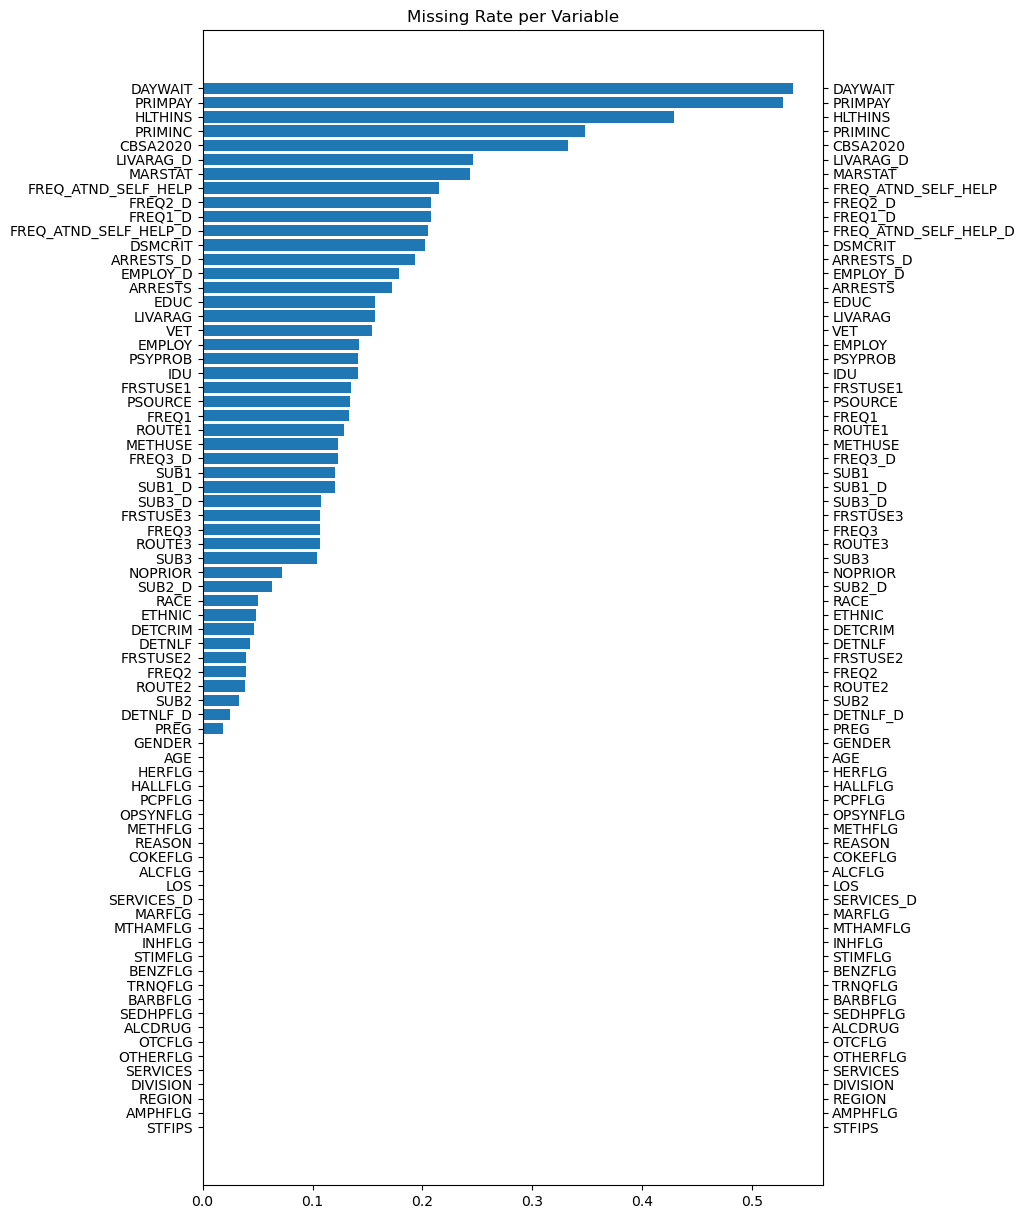

In [ ]:
still_missing = missing_check(data)

# 결측치가 MNAR인지 확인하기


In [ ]:
import pandas as pd
import os
print(os.getcwd())

data_path = os.path.join(os.getcwd(), '..', 'data', 'missing_corrected.csv')
data = pd.read_csv(data_path, index_col=0)
data.head()

/Users/jeong-yunseong/Documents/programming/practiceLabForVAMwithGNN/Phase_2/notebooks


,STFIPS,EDUC,MARSTAT,SERVICES,DETCRIM,LOS,PSOURCE,NOPRIOR,ARRESTS,EMPLOY,...,BARBFLG,SEDHPFLG,INHFLG,OTCFLG,OTHERFLG,DIVISION,REGION,IDU,ALCDRUG,CBSA2020
0,2,3,1,7,0,36,1,1,0,1,...,0,0,0,0,1,9,4,0,3,-9
1,51,3,-9,7,0,1,6,0,0,4,...,0,0,0,0,0,5,3,1,3,-9
2,2,3,1,7,0,34,1,1,0,3,...,0,0,0,0,1,9,4,0,3,-9
3,2,3,-9,7,0,36,1,0,0,1,...,0,0,0,0,0,9,4,1,3,-9
4,2,3,2,7,0,37,1,1,0,1,...,0,0,0,0,0,9,4,0,1,-9


## 통계적으로 확인

### Little's MCAR test

pyampute documentation: https://rianneschouten.github.io/pyampute/build/html/index.html

pyampute github: https://github.com/RianneSchouten/pyampute 

새로운 가상 환경이 필요할듯, AttributeError: 'DataFrame' object has no attribute 'append'

이 문제는 pandas의 옛 버전을 사용하지 않아 생기는 문제

In [ ]:
import numpy as np
# Assuming 'data' is your original DataFrame and you've already done the copy
fill_na_data = data.copy()

fill_na_data = fill_na_data.mask(fill_na_data == -9, np.nan)
# This replaces values where the condition (value == -9) is True with np.nan

In [ ]:
from pyampute.exploration.md_patterns import mdPatterns
mdp = mdPatterns()
patterns = mdp.get_patterns(fill_na_data)
print(patterns)

/opt/miniconda3/envs/mcar/lib/python3.10/site-packages/pyampute/exploration/md_patterns.py:120: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  group_values = group_values.append(colsums, ignore_index=True)
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x107b34790>>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/mcar/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 797, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


In [ ]:
import pandas as pd
from pyampute.exploration.mcar_statistical_tests import MCARTest
mt = MCARTest(method="little")
p_value = mt.little_mcar_test(fill_na_data)

print(f"Little's MCAR Test p-value: {p_value:.10f}")

print(f"Little's MCAR Test p-value (Sci-Notation): {p_value:.5e}")

Little's MCAR Test p-value: 0.0000000000
Little's MCAR Test p-value (Sci-Notation): 0.00000e+00


In [ ]:
mt2 = MCARTest(method="ttest")
mt2.little_mcar_test(fill_na_data)

0.0

## 시각적으로 확인
1. 원핫 인코딩
    - 원핫 인코딩을 할 때 범주 이름이 덮어씌워짐
    - -9가 있는 경우, 가장 처음 범주가 -9가 되도록 순서 정리 (sort했으니까 오름차순, -9 없으면 그 다음 작은 숫자)
2. PCA
    -  선형 변환하여 2-3차원 공간에 매핑


## 원핫 인코딩 하기

In [ ]:
def dtype_convert_cat_help(df: pd.DataFrame, col):
    desired_order = df[col].unique().tolist()
    desired_order.sort(reverse=True)
    df[col] = pd.Categorical(df[col], categories=desired_order, ordered=True)
    return df

def dtype_convert_cat(df: pd.DataFrame):
    for col in df.columns:
        df = dtype_convert_cat_help(df, col)
        print(col, '완료')
    return df

data = dtype_convert_cat(data)


STFIPS 완료
EDUC 완료
MARSTAT 완료
SERVICES 완료
DETCRIM 완료
LOS 완료
PSOURCE 완료
NOPRIOR 완료
ARRESTS 완료
EMPLOY 완료
METHUSE 완료
PSYPROB 완료
PREG 완료
GENDER 완료
VET 완료
LIVARAG 완료
DAYWAIT 완료
SERVICES_D 완료
REASON 완료
EMPLOY_D 완료
LIVARAG_D 완료
ARRESTS_D 완료
DSMCRIT 완료
AGE 완료
RACE 완료
ETHNIC 완료
DETNLF 완료
DETNLF_D 완료
PRIMINC 완료
SUB1 완료
SUB2 완료
SUB3 완료
SUB1_D 완료
SUB2_D 완료
SUB3_D 완료
ROUTE1 완료
ROUTE2 완료
ROUTE3 완료
FREQ1 완료
FREQ2 완료
FREQ3 완료
FREQ1_D 완료
FREQ2_D 완료
FREQ3_D 완료
FRSTUSE1 완료
FRSTUSE2 완료
FRSTUSE3 완료
HLTHINS 완료
PRIMPAY 완료
FREQ_ATND_SELF_HELP 완료
FREQ_ATND_SELF_HELP_D 완료
ALCFLG 완료
COKEFLG 완료
MARFLG 완료
HERFLG 완료
METHFLG 완료
OPSYNFLG 완료
PCPFLG 완료
HALLFLG 완료
MTHAMFLG 완료
AMPHFLG 완료
STIMFLG 완료
BENZFLG 완료
TRNQFLG 완료
BARBFLG 완료
SEDHPFLG 완료
INHFLG 완료
OTCFLG 완료
OTHERFLG 완료
DIVISION 완료
REGION 완료
IDU 완료
ALCDRUG 완료
CBSA2020 완료


In [ ]:
data['DAYWAIT'].unique()

'''
Categories (6, int64): [4 < 3 < 2 < 1 < 0 < -9]
이런 식으로 앞의 Category 순서 정할 때 reverse=True로 해야 -9를 맨 뒤로 보낼 수 있음
이후에 원핫 인코딩 할 때 다중공선성 문제를 조금이나마 예방하고, 계산 비용을 조금이나마 줄이기 위해서 
drop_first=True를 사용할 때 -9를 날리지 않을 수 있음

이 다음으로 해야 할 것음
1. 시각화
예를 들어 DAYWAIT에서 -9인 케이스와 -9가 아닌 케이스들을 다른 색깔 점으로 찍은 다음
이들이 골고루 흩뿌려져 있다면 결측치가 랜덤하게 분포하는 것으로 생각할 수 있음
만약 어떤 패턴이 확인된다면 이건 랜덤하게 분포하는 것이 아님

2. KNN imputation 진행
PCA를 잘 진행한 다음에 KNN 보간법 활용
PCA는 truncatedSVD가 좋다고 함, 그 이유는 무엇인지, 어떤 원리로 작동하는지 공부해야 함
no-skip을 하는 걸로 생각하기
예를 들어 -9도 하나의 범주로 보고,
주위 이웃들에서 -9가 최빈값이라면 -9를 그대로 사용하기
그게 아니라면 다른 값으로 바꾸기
'''

'\nCategories (6, int64): [4 < 3 < 2 < 1 < 0 < -9]\n이런 식으로 앞의 Category 순서 정할 때 reverse=True로 해야 -9를 맨 뒤로 보낼 수 있음\n이후에 원핫 인코딩 할 때 다중공선성 문제를 조금이나마 예방하고, 계산 비용을 조금이나마 줄이기 위해서 \ndrop_first=True를 사용할 때 -9를 날리지 않을 수 있음\n\n이 다음으로 해야 할 것음\n1. 시각화\n예를 들어 DAYWAIT에서 -9인 케이스와 -9가 아닌 케이스들을 다른 색깔 점으로 찍은 다음\n이들이 골고루 흩뿌려져 있다면 결측치가 랜덤하게 분포하는 것으로 생각할 수 있음\n만약 어떤 패턴이 확인된다면 이건 랜덤하게 분포하는 것이 아님\n\n2. KNN imputation 진행\nPCA를 잘 진행한 다음에 KNN 보간법 활용\nPCA는 truncatedSVD가 좋다고 함, 그 이유는 무엇인지, 어떤 원리로 작동하는지 공부해야 함\nno-skip을 하는 걸로 생각하기\n예를 들어 -9도 하나의 범주로 보고,\n주위 이웃들에서 -9가 최빈값이라면 -9를 그대로 사용하기\n그게 아니라면 다른 값으로 바꾸기\n'

In [ ]:
onehotencoded = pd.get_dummies(
    data, 
    columns=list(data.columns), 
    drop_first=True,
    # 메모리 사용을 줄이는 핵심 옵션
    sparse=True 
)
# 희소 데이터프레임을 밀집된(Dense) NumPy 배열로 변환
onehot_sparse_array = onehotencoded.sparse.to_coo()

가짜 결측치 처리된 데이터 저장하기

## 여전히 결측률이 심한 변수들에 대한 분석

Statistical hypothesis test for Missing Completely At Random (MCAR)

https://rianneschouten.github.io/pyampute/build/html/pyampute.exploration.html

KNN을 하더라도 시작하기 전에 uniformly distributed in at random in dataset인지 증명해야 함

아주 희망적인 소식, MNAR이더라도 KNN을 수행하는 방법 (No-Skip kNN (NS-kNN))
https://pmc.ncbi.nlm.nih.gov/articles/PMC6532628/ 

# KNN imputation

7.4. Imputation of missing values

https://scikit-learn.org/stable/modules/impute.html# 

KNNImputer

https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html


## 범주형 변수를 수치형 벡터로 변환

## PCA를 통한 선형 변환

## KNN imputation 적용

# LOS 비율 확인하기 + 시각화

In [5]:
LOS_ = raw_data['LOS'].value_counts().sort_index() / len(raw_data)
print(LOS_)

import matplotlib.pyplot as plt
x = LOS_.index
y = LOS_.to_list()
plt.bar(x, y)
plt.title("Proportions in LOS")
plt.ylabel("0 ~ 1")
plt.show()

NameError: name 'raw_data' is not defined

다른 곳으로 이송 당했기 때문에 LOS의 1이 많이 나온 것 아닐까?
- 다음은 LOS가 1일 때 REASON의 비율

In [6]:
raw_data['REASON'][raw_data['LOS'] == 1].value_counts() / sum(raw_data['LOS'] == 1)

# 4. Transferred to another treatment program or facility  -> 0.478106
# 1. Treatment completed -> 0.385353
# 둘이 합하면 0.86
# 2. Dropped out of treatment -> 0.098168
# 셋이 합하면 0.96

NameError: name 'raw_data' is not defined

In [1]:
import os
import pandas as pd


cur_dir = os.getcwd()
missing_corr_path = os.path.join(cur_dir, '..', 'data', 'missing_corrected.csv')

df = pd.read_csv(missing_corr_path)
df.columns

Index(['STFIPS', 'EDUC', 'MARSTAT', 'SERVICES', 'DETCRIM', 'LOS', 'PSOURCE',
       'NOPRIOR', 'ARRESTS', 'EMPLOY', 'METHUSE', 'PSYPROB', 'PREG', 'GENDER',
       'VET', 'LIVARAG', 'DAYWAIT', 'SERVICES_D', 'EMPLOY_D', 'LIVARAG_D',
       'ARRESTS_D', 'DSMCRIT', 'AGE', 'RACE', 'ETHNIC', 'DETNLF', 'DETNLF_D',
       'PRIMINC', 'SUB1', 'SUB2', 'SUB3', 'SUB1_D', 'SUB2_D', 'SUB3_D',
       'ROUTE1', 'ROUTE2', 'ROUTE3', 'FREQ1', 'FREQ2', 'FREQ3', 'FREQ1_D',
       'FREQ2_D', 'FREQ3_D', 'FRSTUSE1', 'FRSTUSE2', 'FRSTUSE3', 'HLTHINS',
       'PRIMPAY', 'FREQ_ATND_SELF_HELP', 'FREQ_ATND_SELF_HELP_D', 'ALCFLG',
       'COKEFLG', 'MARFLG', 'HERFLG', 'METHFLG', 'OPSYNFLG', 'PCPFLG',
       'HALLFLG', 'MTHAMFLG', 'AMPHFLG', 'STIMFLG', 'BENZFLG', 'TRNQFLG',
       'BARBFLG', 'SEDHPFLG', 'INHFLG', 'OTCFLG', 'OTHERFLG', 'DIVISION',
       'REGION', 'IDU', 'ALCDRUG', 'CBSA2020', 'REASONb'],
      dtype='object')

In [3]:
df["REASONb"][df["ARRESTS_D"] != 0].value_counts() / len(df)

REASONb
0    0.123966
1    0.117064
Name: count, dtype: float64